<a href="https://colab.research.google.com/github/amanpoonia/IV_closedform_BlackScholes/blob/main/MC_portfolio_value.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from pandas_datareader import data as pdr
import yfinance as yf


In [33]:
#import data
def get_data(stocks, start, end):
  #we want to return covariance matrix and mean returns
  stockdata = yf.download(stocks, start, end)
  print(stockdata.head())
  stockdata = stockdata['Close']
  returns = stockdata.pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()
  return meanReturns, covMatrix

In [39]:
stockList = ['AAPL', 'GS', 'MS']
#stocks = [stock + '.AX' for stock in stockList]
stocks = stockList
endDate = dt.datetime.now()
startDate = endDate - dt.timedelta(days=300)



In [40]:
meanReturns, covMatrix = get_data(stocks, startDate, endDate)

/tmp/ipykernel_17631/431636841.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stockdata = yf.download(stocks, start, end)
[*********************100%***********************]  3 of 3 completed

Price            Close                                High              \
Ticker            AAPL          GS          MS        AAPL          GS   
Date                                                                     
2025-07-07  209.313049  699.972351  140.352371  215.573996  712.811342   
2025-07-08  209.372849  686.532776  137.803894  210.788539  700.228353   
2025-07-09  210.499435  685.823914  138.213989  210.688861  693.484029   
2025-07-10  211.765579  698.190247  139.717697  212.832325  699.430836   
2025-07-11  210.519379  694.084595  138.926773  211.486437  695.118399   

Price                          Low                                Open  \
Ticker              MS        AAPL          GS          MS        AAPL   
Date                                                                     
2025-07-07  141.738903  208.166544  695.453131  139.141590  212.034763   
2025-07-08  140.664834  207.817584  683.076866  137.696486  209.462587   
2025-07-09  139.571230  206.591330  6

In [41]:
print(meanReturns)

Ticker
AAPL    0.001512
GS      0.001492
MS      0.001604
dtype: float64


In [42]:
mc_sims = 100
T = 100

weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)
print(weights)

[0.30335883 0.56037373 0.13626744]


In [54]:
portfolio_sims = np.full(shape=(T, mc_sims), fill_value=0.0)
meanM = np.full(shape=(T, len(weights)), fill_value = meanReturns)
meanM = meanM.T

In [55]:
initialPortfolio = 10000

In [57]:
#MC simulations
for m in range(mc_sims):
  z = np.random.normal(size=(T, len(weights)))
  L = np.linalg.cholesky(covMatrix)
  dailyReturns = meanM + np.inner(L, z)
  portfolio_sims[:, m] = np.cumprod(np.inner(weights, dailyReturns.T) + 1)*initialPortfolio


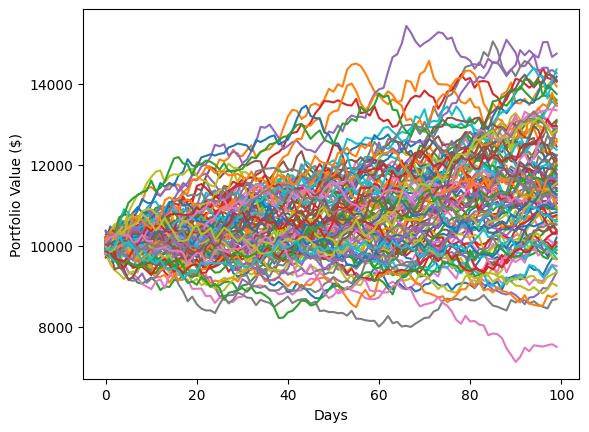

In [58]:
plt.plot(portfolio_sims)
plt.ylabel('Portfolio Value ($)')
plt.xlabel('Days')
plt.show()

### Simplified Matrix Example for Monte Carlo Simulation

Let's walk through the core matrix operations with smaller values to make it easier to grasp.

In [ ]:
print('--- Setup Simplified Example ---')

# Simplified parameters
sim_T = 3 # Simulate for 3 days
sim_num_stocks = 2 # Two stocks
sim_mc_sims = 1 # Just one simulation for clarity
sim_initialPortfolio = 100

# Simplified mean returns and covariance matrix
sim_meanReturns = np.array([0.001, 0.002]) # Stock A, Stock B
sim_covMatrix = np.array([[0.0001, 0.00005], [0.00005, 0.0002]])
sim_weights = np.array([0.5, 0.5]) # 50/50 split

print(f"\nSimplified Mean Returns: {sim_meanReturns}")
print(f"Simplified Covariance Matrix:\n{sim_covMatrix}")
print(f"Simplified Weights: {sim_weights}")

In [ ]:
print('\n--- Step 1: Generate Random Shocks (z) ---')
# z = np.random.normal(size=(T, len(weights)))
sim_z = np.random.normal(size=(sim_T, sim_num_stocks))
print(f"Generated random normal deviates (z) for {sim_T} days and {sim_num_stocks} stocks:\n{sim_z}")

print('\n--- Step 2: Cholesky Decomposition of Covariance Matrix (L) ---')
# L = np.linalg.cholesky(covMatrix)
sim_L = np.linalg.cholesky(sim_covMatrix)
print(f"Cholesky decomposed matrix (L):\n{sim_L}")

print('\n--- Step 3: Create Mean Matrix (meanM) ---')
# meanM = np.full(shape=(T, len(weights)), fill_value = meanReturns).T
sim_meanM = np.full(shape=(sim_T, sim_num_stocks), fill_value=sim_meanReturns).T
print(f"Mean Returns Matrix (meanM) repeated for {sim_T} days:\n{sim_meanM}")

In [ ]:
print('\n--- Step 4: Calculate Correlated Daily Returns ---')
# np.inner(L, z)
# This projects the random shocks onto the covariance structure
sim_correlated_shocks = np.inner(sim_L, sim_z)
print(f"Correlated Shocks (L @ z):\n{sim_correlated_shocks}")

# dailyReturns = meanM + np.inner(L, z)
sim_dailyReturns = sim_meanM + sim_correlated_shocks
print(f"Simulated Daily Returns (meanM + L @ z):\n{sim_dailyReturns}")

In [ ]:
print('\n--- Step 5: Calculate Portfolio Value over Time ---')
# np.inner(weights, dailyReturns.T)
# This is the weighted average daily return for the portfolio
sim_portfolio_daily_return_percentages = np.inner(sim_weights, sim_dailyReturns.T)
print(f"Portfolio Daily Return Percentages:\n{sim_portfolio_daily_return_percentages}")

# + 1 to convert to growth factors
sim_portfolio_daily_growth_factors = sim_portfolio_daily_return_percentages + 1
print(f"Portfolio Daily Growth Factors:\n{sim_portfolio_daily_growth_factors}")

# np.cumprod(...) * initialPortfolio
# Cumulative product to get portfolio value over time
sim_portfolio_sim_path = np.cumprod(sim_portfolio_daily_growth_factors) * sim_initialPortfolio
print(f"Simulated Portfolio Value Path over {sim_T} days:\n{sim_portfolio_sim_path}")

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt

In [22]:
def data_down(stocks, start, end):
  prices = yf.download(stocks, start, end)
  prices = prices['Close']
  returns = prices.pct_change()
  meanReturns = returns.mean()
  covMatrix = returns.cov()

  return meanReturns, covMatrix

In [23]:
stockList = ['AAPL', 'MS', 'GS']
end_date = dt.datetime.now()
start_date = end_date - dt.timedelta(days=300)

In [27]:
meanReturns, covMatrix = data_down(stockList, start_date, end_date)
meanReturns

/tmp/ipykernel_2689/1833085898.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(stocks, start, end)
[*********************100%***********************]  3 of 3 completed


,0
Ticker,
AAPL,0.001518
GS,0.001592
MS,0.001700


Now lets generate data for simulations

In [42]:
mc_sims = 100
T = 100
initial_portfolio = 1000

In [26]:
weights = np.random.random(len(meanReturns))
weights /= np.sum(weights)
print(weights)

[0.27045725 0.30995336 0.4195894 ]


In [40]:
portfolio_value = np.full(shape=(mc_sims, T), fill_value = 0.0)
meanM = np.full(shape=(T, len(meanReturns)), fill_value = meanReturns)
meanM = meanM.T

In [50]:
for m in range(mc_sims):
  L = np.linalg.cholesky(covMatrix)
  Z = np.random.normal(size=(T, len(meanReturns)))
  dailyReturns = meanM + np.inner(L,Z)

  portfolio_value[:,m] = np.cumprod(np.inner(dailyReturns.T, weights)+1)*initial_portfolio

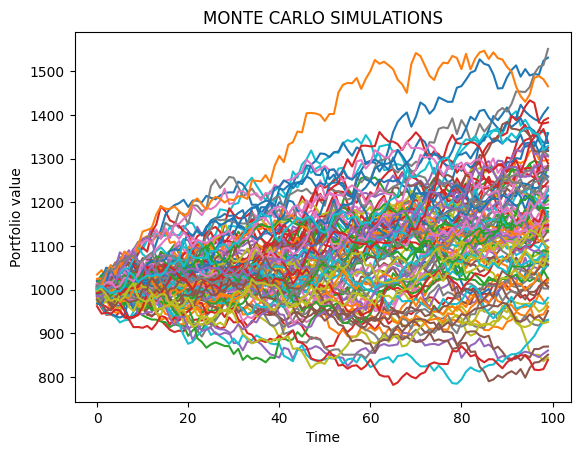

In [51]:
plt.plot(portfolio_value)
plt.ylabel("Portfolio value")
plt.xlabel("Time")
plt.title("MONTE CARLO SIMULATIONS")
plt.show()

Below is the cholesky decomposition, normal distribution

In [32]:
L = np.linalg.cholesky(covMatrix)
L

array([[0.01445285, 0.        , 0.        ],
       [0.0056501 , 0.01643914, 0.        ],
       [0.00603139, 0.01222827, 0.0092644 ]])

In [49]:
Z = np.random.normal(size=(len(meanReturns),T))


In [41]:
L = np.linalg.cholesky(covMatrix)
Z = np.random.normal(size=(T, len(meanReturns)))
dailyReturns = meanM + np.inner(L,Z)

portfolio_value[:,m] = np.cumprod(np.inner(weights, dailyReturns)+1)*initial_portfolio

array([[-1.01879049e-02,  7.74346597e-04,  7.00094834e-03,
        -4.89244399e-03,  1.78500442e-02,  4.90413969e-03,
         1.65952184e-02, -1.66015587e-02, -9.87123845e-03,
        -2.37565827e-03,  1.60667989e-02, -1.49236759e-02,
        -1.35008458e-03,  1.97866889e-02,  1.06010388e-02,
         2.07354003e-02,  3.37529403e-04,  4.47382016e-03,
         3.19008936e-02,  1.31597119e-02,  1.72339921e-02,
         3.52844072e-03, -1.40242651e-02, -1.44489397e-02,
        -1.91208381e-02, -8.45480987e-03,  1.94412305e-02,
        -6.24107915e-04,  9.84938307e-03,  4.81127747e-04,
        -3.27834402e-02, -1.16898211e-02, -2.48634791e-02,
         4.85039116e-03,  3.44455978e-02,  1.18712331e-02,
        -1.38016381e-02,  5.51046484e-03, -3.61274220e-02,
         7.38363458e-04,  6.30249539e-03, -4.69461728e-03,
         8.03423981e-03,  4.96526278e-03,  4.63636354e-03,
        -2.36172958e-03,  2.36146617e-02, -1.73465814e-02,
         1.61544807e-02, -5.36116952e-03, -1.85521647e-0